## Demo embedding extraction

This notebook shows how to use the embedding extraction module for generating numerical representation using the pre-trained models.

The following family of pre-trained models is available for testing

- Prot5Based
- ESMBasedEmbedding
- Ankh2BasedEmbedding
- BertBasedMebedding
- MistralBasedEmbedding

In [28]:
import warnings
warnings.filterwarnings("ignore")

In [29]:
import sys
sys.path.insert(0, "../src/")

In [30]:
import pandas as pd

- Loading modules

In [31]:
from embedding_extraction.prot5_based import Prot5Based
from embedding_extraction.esm_based import ESMBasedEmbedding
from embedding_extraction.bert_based import BertBasedMebedding
from embedding_extraction.mistral_based import MistralBasedEmbedding
from dimensionality_reductions.non_linear_reductions import NonLinearReductions

In [32]:
import seaborn as sns

- Read AMP dataset and select only 10 examples

In [33]:
df_data = pd.read_csv("../raw_data/Antimicrobial/train_data.csv")
df_pos = df_data[df_data["label"] == 1][:50]
df_neg = df_data[df_data["label"] == 0][:50]

df_data = pd.concat([df_pos, df_neg], axis=0)

df_data.head(5)

,sequence,label
2,SKGKKANKDVELARG,1
3,ADLEVVAATYVLVA,1
8,AISCGQVSSALSPCISYARGNGAKPPVACCSGVKRLAGAAQSTADK...,1
10,KKKKLLLPFLFFF,1
11,EPTAEDSVMVKRSIGSAFKKALPVAKKIGKAALPIAKAALPVVA,1


### ProT5 evaluation

In [ ]:
df_to_prot5 = df_data.copy()
df_to_prot5["sequence"] = df_to_prot5["sequence"].apply(lambda x: " ".join(x)) # this process is necessary for the application of the pre-trained model

prot5_based = Prot5Based(
    name_device="cuda",
    dataset=df_to_prot5,
    name_model="Rostlab/ProstT5",
    name_tokenizer="Rostlab/ProstT5",
    column_seq="sequence",
    columns_ignore=["label"],
)

print("Loading model/tokenizer")
prot5_based.load_model_tokenizer()

print("Generating embedding")
df_embedding = prot5_based.embedding_process(batch_size=5)

prot5_based.cleaning_memory()
print("Process finished")

df_embedding

<Axes: xlabel='p_1', ylabel='p_2'>

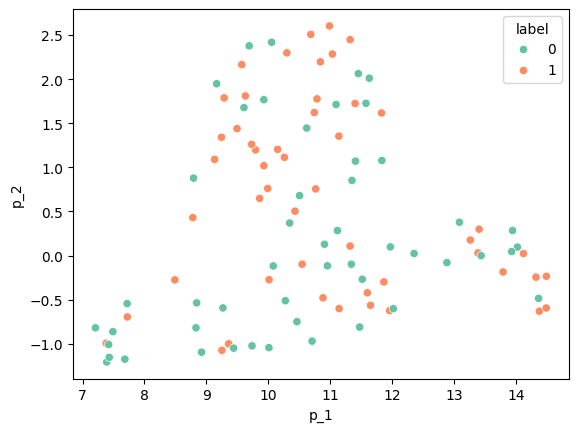

In [ ]:
df_values = df_embedding.drop(columns=["label"])
nonlinear_instance = NonLinearReductions(dataset=df_values)

transform_values_umap = nonlinear_instance.applyUMAP()
transform_values_umap["label"] = df_embedding["label"].values

sns.scatterplot(data=transform_values_umap, x="p_1", y="p_2", hue="label", palette="Set2")


### ESM evaluation

In [ ]:
esm_based = ESMBasedEmbedding(
    name_device="cuda",
    dataset=df_data,
    name_model="facebook/esm2_t6_8M_UR50D",
    name_tokenizer="facebook/esm2_t6_8M_UR50D",
    column_seq="sequence",
    columns_ignore=["label"],
)

print("Loading model/tokenizer")
esm_based.load_model_tokenizer()

print("Generating embedding")
df_embedding = esm_based.embedding_process(batch_size=5)

esm_based.cleaning_memory()
print("Process finished")

df_embedding

Using device:  cuda
Loading model/tokenizer


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Generating embedding


[+] Embedding: 100%|██████████| 20/20 [00:00<00:00, 62.24batch/s]

Empty cache memory
Process finished


,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,p_9,p_10,...,p_312,p_313,p_314,p_315,p_316,p_317,p_318,p_319,p_320,label
0,0.038753,-0.466662,0.177320,0.283447,-0.157254,-0.210455,0.032250,-0.592629,-0.086694,-0.632122,...,-0.006170,0.114515,0.451836,-0.037412,0.432273,0.025891,0.235815,-0.294218,-0.099969,1
1,-0.102849,-0.027011,0.220620,-0.137865,-0.080101,-0.169420,0.028098,-0.763410,-0.191365,-0.453428,...,0.165928,0.072348,0.426974,-0.076858,0.324258,0.131072,0.272085,-0.365543,-0.174261,1
2,-0.164572,0.084614,0.070991,0.091308,-0.123479,0.040149,-0.187767,-0.188999,-0.109216,0.036542,...,0.125002,0.057439,0.065273,-0.269063,-0.287047,-0.248607,0.156173,-0.035435,0.146348,1
3,-0.285582,-0.431369,0.389113,0.626210,-0.274035,0.073600,0.230880,-0.463638,0.049846,-0.429572,...,-0.135858,-0.041114,0.158228,0.040886,0.402701,0.188948,0.074313,0.237462,0.117591,1
4,-0.331187,0.264146,0.174320,0.285864,-0.242214,-0.109342,-0.041587,-0.424624,-0.071376,-0.148256,...,0.166234,-0.074651,0.421750,0.098968,0.132208,0.038314,0.338621,-0.463522,-0.024346,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.053822,0.003931,0.150068,0.269714,-0.013588,-0.221242,-0.265617,-0.226425,0.028132,-0.095766,...,-0.122343,0.067419,-0.052607,-0.177739,-0.181906,-0.080015,-0.055434,0.119585,-0.053657,0
96,-0.077519,-0.115865,0.214522,0.024664,-0.117902,-0.080992,0.221583,-0.765849,-0.024934,-0.543199,...,0.003488,0.089683,0.584557,0.162240,0.305446,0.139752,0.223493,-0.674330,-0.395166,0
97,-0.114588,-0.416198,0.150612,0.098640,-0.399007,-0.252783,0.028891,-0.821431,0.013800,-0.549518,...,0.131501,0.243913,0.490645,-0.008939,0.439244,-0.039254,0.124795,-0.416302,-0.064010,0
98,0.035486,-0.147592,0.185308,0.119941,-0.173628,-0.194837,-0.030451,-0.686783,-0.182324,-0.435326,...,-0.041213,-0.013722,0.482606,-0.095396,0.443735,0.149745,0.456722,-0.364119,-0.278319,0


<Axes: xlabel='p_1', ylabel='p_2'>

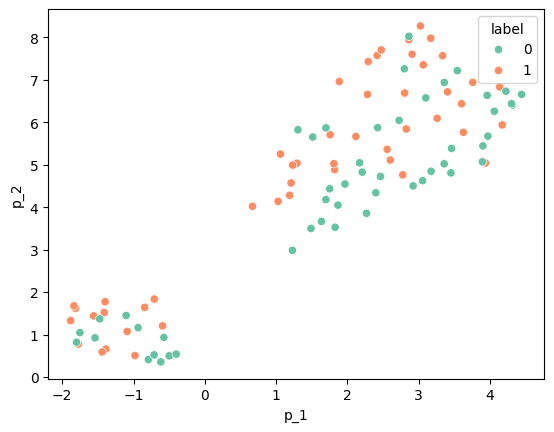

In [ ]:
df_values = df_embedding.drop(columns=["label"])
nonlinear_instance = NonLinearReductions(dataset=df_values)

transform_values_umap = nonlinear_instance.applyUMAP()
transform_values_umap["label"] = df_embedding["label"].values

sns.scatterplot(data=transform_values_umap, x="p_1", y="p_2", hue="label", palette="Set2")


### Bert evaluation

In [ ]:
df_to_bert = df_data.copy()
df_to_bert["sequence"] = df_to_bert["sequence"].apply(lambda x: " ".join(x)) # this process is necessary for the application of the pre-trained model

bert_based = BertBasedMebedding(
    name_device="cuda",
    dataset=df_to_bert,
    name_model="Rostlab/prot_bert_bfd_ss3",
    name_tokenizer="Rostlab/prot_bert_bfd_ss3",
    column_seq="sequence",
    columns_ignore=["label"],
)

print("Loading model/tokenizer")
bert_based.load_model_tokenizer()

print("Generating embedding")
df_embedding = bert_based.embedding_process(batch_size=5)

bert_based.cleaning_memory()
print("Process finished")

df_embedding

Using device:  cuda
Loading model/tokenizer


Some weights of BertModel were not initialized from the model checkpoint at Rostlab/prot_bert_bfd_ss3 and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Generating embedding


[+] Embedding: 100%|██████████| 20/20 [00:01<00:00, 17.11batch/s]

Empty cache memory
Process finished


,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,p_9,p_10,...,p_1016,p_1017,p_1018,p_1019,p_1020,p_1021,p_1022,p_1023,p_1024,label
0,0.253796,-0.120789,0.087071,-0.067594,0.470305,0.067136,-0.102264,0.143320,0.117124,0.234838,...,-0.771810,0.060689,0.035275,0.100438,-0.085473,-0.418161,-0.066689,0.051639,0.067722,1
1,0.328857,-0.102377,0.002030,-0.056353,0.399721,0.122910,-0.154262,0.020239,0.156599,0.194406,...,-0.743961,0.024980,0.037036,0.055841,-0.094317,-0.427395,-0.029176,-0.045183,0.066857,1
2,0.266153,-0.080143,0.037093,-0.075352,0.463861,0.103116,-0.080729,0.064753,0.041248,0.178344,...,-0.699384,0.032242,0.003700,0.056654,-0.028702,-0.390443,-0.077979,-0.103043,0.052299,1
3,0.222402,-0.188651,0.167486,0.022429,0.666284,0.008978,-0.087213,-0.007852,0.143014,0.090999,...,-0.695783,0.010647,0.094000,0.058832,-0.126345,-0.195172,0.006176,-0.004757,0.124636,1
4,0.295346,-0.203191,0.018733,-0.071689,0.515917,0.051763,-0.110895,0.094729,0.081993,0.184451,...,-0.793901,0.029948,0.033867,0.169547,-0.158287,-0.435423,-0.033731,-0.030026,-0.003192,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.185052,-0.266378,-0.052630,0.080263,0.329121,0.009078,-0.130230,-0.195461,0.067941,-0.048289,...,-0.494161,-0.161063,0.125250,-0.100988,-0.116674,-0.201880,0.052734,-0.098880,-0.019108,0
96,0.120408,-0.264132,0.162348,-0.072479,0.557292,-0.012310,-0.121896,-0.101899,0.098958,0.064041,...,-0.605043,-0.048104,0.128926,-0.108042,-0.131809,-0.086488,-0.009533,-0.000095,0.021435,0
97,0.291180,-0.226778,-0.013225,0.031337,0.446870,0.114112,-0.252370,-0.033789,0.044356,0.187486,...,-0.660408,-0.083600,0.051577,0.084823,-0.129254,-0.410359,0.012994,-0.032166,0.040844,0
98,0.222287,-0.125676,0.137126,-0.022779,0.561332,0.132459,-0.110485,0.062254,0.097909,0.194713,...,-0.739160,0.039816,0.038039,0.130240,-0.079596,-0.331854,-0.064945,0.001326,0.069613,0


<Axes: xlabel='p_1', ylabel='p_2'>

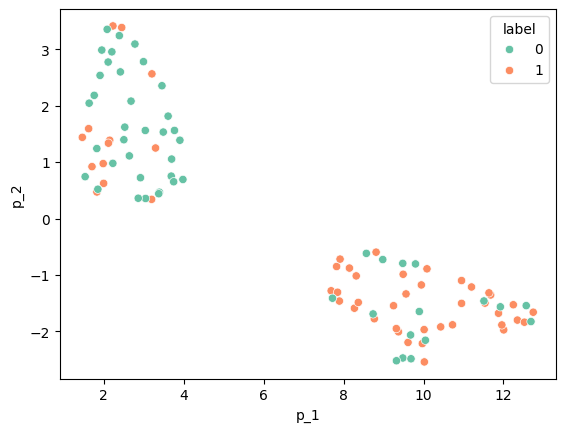

In [ ]:
df_values = df_embedding.drop(columns=["label"])
nonlinear_instance = NonLinearReductions(dataset=df_values)

transform_values_umap = nonlinear_instance.applyUMAP()
transform_values_umap["label"] = df_embedding["label"].values

sns.scatterplot(data=transform_values_umap, x="p_1", y="p_2", hue="label", palette="Set2")
